In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso,RidgeCV
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import  RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import KNNImputer
import itertools
import warnings
warnings.filterwarnings("ignore")

In [31]:
df = pd.read_csv("E:\\VS code\\Applied_programming(IT park)\\New folder\\taxi_trip_pricing.csv")

In [32]:
df.shape


(1000, 11)

In [33]:
df.head(2)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN


In [34]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

<Axes: >

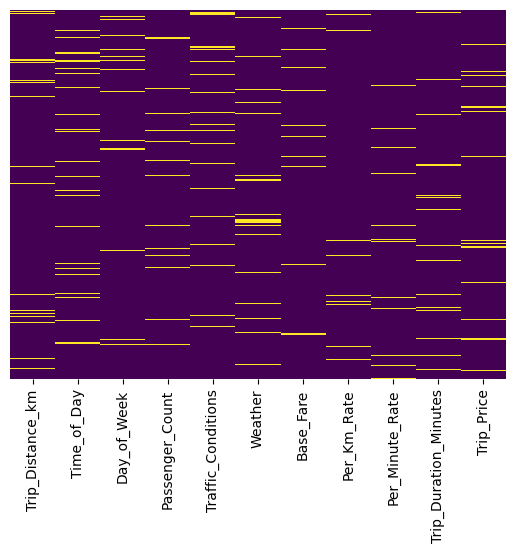

In [35]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [36]:
df.duplicated().sum()


np.int64(0)

In [37]:
df.T.duplicated()

Trip_Distance_km         False
Time_of_Day              False
Day_of_Week              False
Passenger_Count          False
Traffic_Conditions       False
Weather                  False
Base_Fare                False
Per_Km_Rate              False
Per_Minute_Rate          False
Trip_Duration_Minutes    False
Trip_Price               False
dtype: bool

In [38]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [40]:
df['Time_of_Day'].value_counts(), df['Day_of_Week'].value_counts(), df['Traffic_Conditions'].value_counts(), df['Weather'].value_counts()

(Time_of_Day
 Afternoon    371
 Morning      283
 Evening      203
 Night         93
 Name: count, dtype: int64,
 Day_of_Week
 Weekday    655
 Weekend    295
 Name: count, dtype: int64,
 Traffic_Conditions
 Low       397
 Medium    371
 High      182
 Name: count, dtype: int64,
 Weather
 Clear    667
 Rain     227
 Snow      56
 Name: count, dtype: int64)

In [41]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [42]:
df.describe(include="object")

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
count,950,950,950,950
unique,4,2,3,3
top,Afternoon,Weekday,Low,Clear
freq,371,655,397,667


In [43]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

In [44]:
for col in cat_cols:
    print(f"Unique values for {col}:", df[col].unique())

Unique values for Time_of_Day: ['Morning' 'Afternoon' 'Evening' 'Night' nan]
Unique values for Day_of_Week: ['Weekday' 'Weekend' nan]
Unique values for Traffic_Conditions: ['Low' 'High' 'Medium' nan]
Unique values for Weather: ['Clear' nan 'Rain' 'Snow']


In [45]:
imputer = KNNImputer(n_neighbors=3)
df[num_cols] = imputer.fit_transform(df[num_cols])

In [46]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [47]:
df.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [48]:
corr = df[num_cols].corr().abs()
corr

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,0.043362,0.033429,0.012099,0.036458,0.014633,0.832089
Passenger_Count,0.043362,1.000000,0.021095,0.031574,0.038451,0.036281,0.007320
Base_Fare,0.033429,0.021095,1.000000,0.000681,0.025688,0.012525,0.034457
Per_Km_Rate,0.012099,0.031574,0.000681,1.000000,0.039766,0.037732,0.261752
Per_Minute_Rate,0.036458,0.038451,0.025688,0.039766,1.000000,0.020828,0.120573
Trip_Duration_Minutes,0.014633,0.036281,0.012525,0.037732,0.020828,1.000000,0.224306
Trip_Price,0.832089,0.007320,0.034457,0.261752,0.120573,0.224306,1.000000


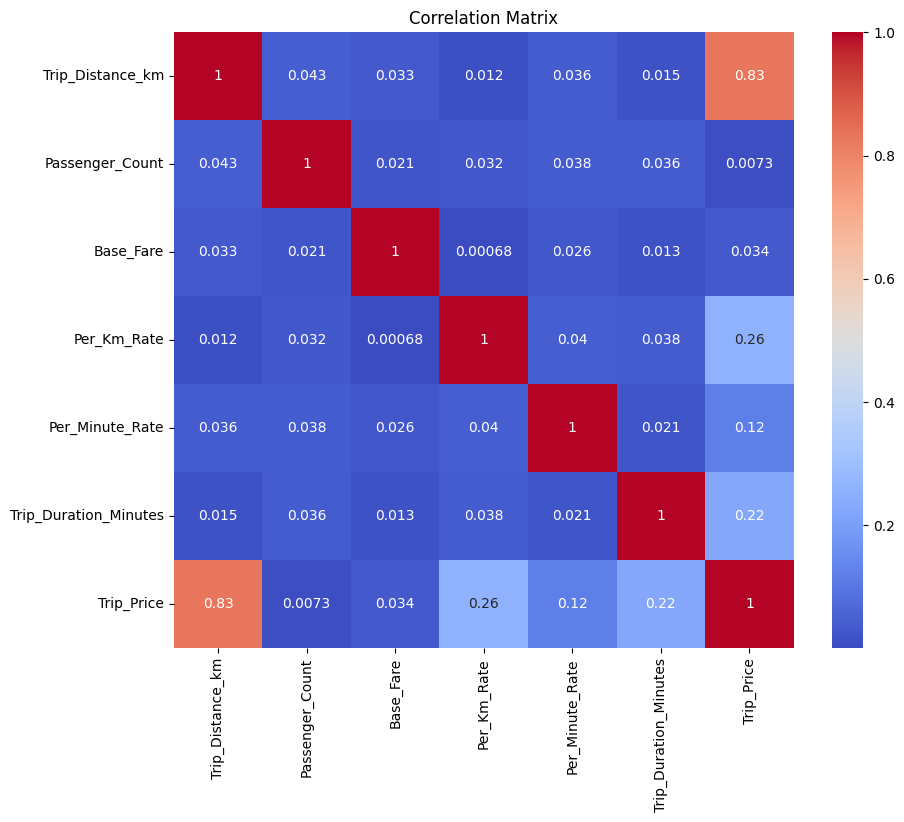

In [49]:
#Correlation Check (Numeric)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [50]:
threshold = 0.85
upper_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
to_drop = [
    column for column in upper_corr.columns
    if any(upper_corr[column] > threshold)
]
to_drop

[]

In [51]:
df = pd.get_dummies(df, columns = cat_cols, drop_first = True)

In [52]:
df.head(2)


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.35,3.0,3.560000,0.80,0.32,53.82,36.2624,False,True,False,False,True,False,False,False
1,47.59,1.0,3.573333,0.62,0.43,40.57,44.5984,False,False,False,False,False,False,False,False


In [53]:
X = df.drop('Trip_Price', axis = 1)
y = df['Trip_Price']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [56]:
models={
    "Linear Regression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "SVR": SVR(kernel = 'rbf'),
    "KNN":KNeighborsRegressor(n_neighbors=5),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "Random Forest":RandomForestRegressor(random_state=42),
}

MAE     : 9.78
MSE     : 192.58
RMSE    : 13.88
R² Score: 0.7691


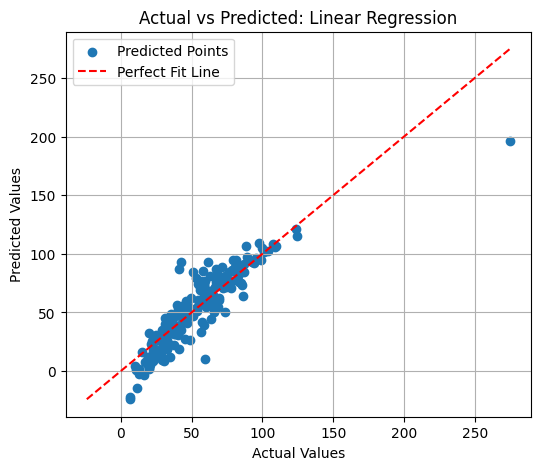

MAE     : 9.92
MSE     : 194.32
RMSE    : 13.94
R² Score: 0.7670


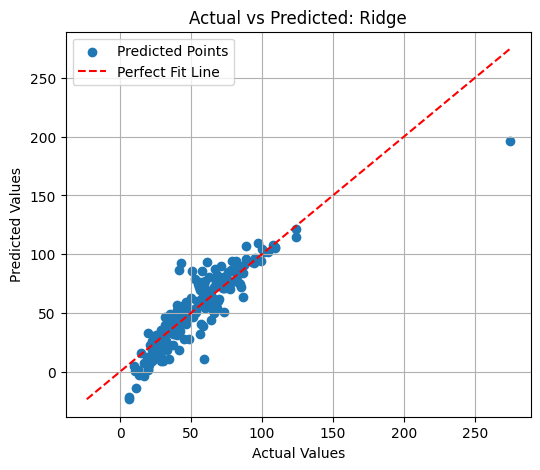

MAE     : 11.90
MSE     : 241.42
RMSE    : 15.54
R² Score: 0.7105


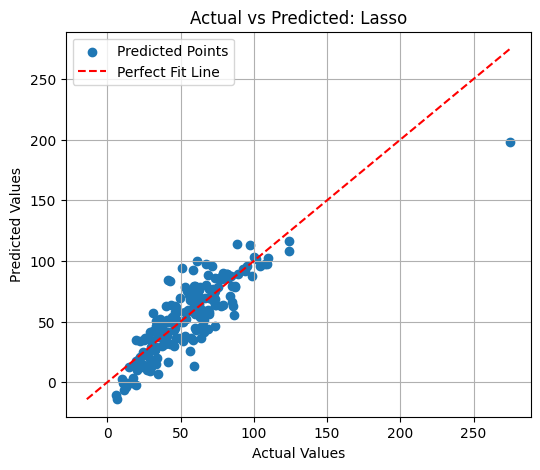

MAE     : 14.22
MSE     : 454.25
RMSE    : 21.31
R² Score: 0.4553


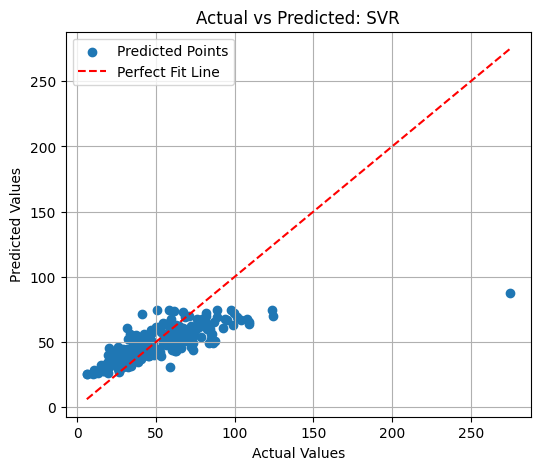

MAE     : 12.69
MSE     : 249.16
RMSE    : 15.78
R² Score: 0.7012


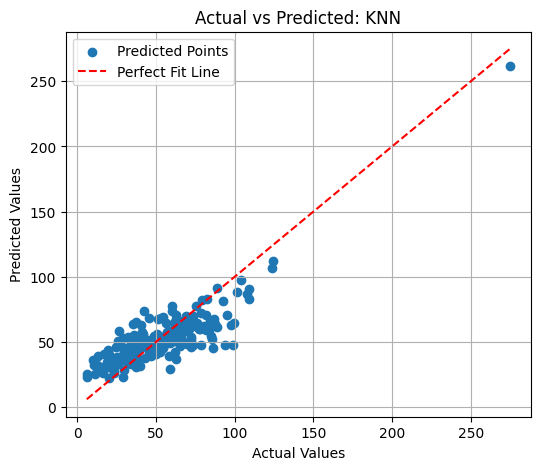

MAE     : 8.59
MSE     : 143.89
RMSE    : 12.00
R² Score: 0.8275


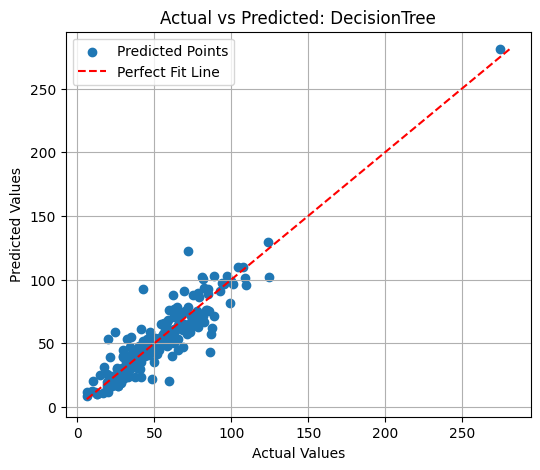

MAE     : 5.29
MSE     : 56.15
RMSE    : 7.49
R² Score: 0.9327


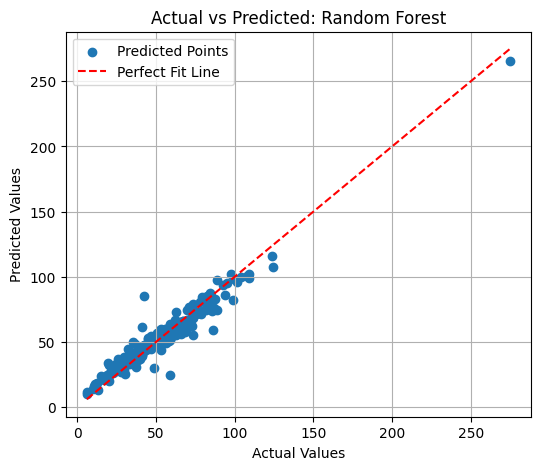

In [57]:


results = []

for name, model in models.items():

    # Fit depending on scaling
    if name in ["Linear Regression", "Ridge", "Lasso", "SVR", "DecisionTree", "Random Forest"]:
        model.fit(X_train, y_train)
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        pred_train = model.predict(X_train_scaled)
        pred_test = model.predict(X_test_scaled)

    # Metrics
    train_mae = mean_absolute_error(y_train, pred_train)
    train_mse = mean_squared_error(y_train, pred_train)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, pred_train)

    test_mae = mean_absolute_error(y_test, pred_test)
    test_mse = mean_squared_error(y_test, pred_test)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, pred_test)

    print(f"MAE     : {test_mae:.2f}")
    print(f"MSE     : {test_mse:.2f}")
    print(f"RMSE    : {test_rmse:.2f}")
    print(f"R² Score: {test_r2:.4f}")

    results.append({
        "Name": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2,

    })

    #Actual vs Predicted Scatter 
    plt.figure(figsize=(6,5))
    plt.scatter(y_test, pred_test, label="Predicted Points")
    min_val = min(min(y_test), min(pred_test))
    max_val = max(max(y_test), max(pred_test))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Fit Line")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted: {name}")
    plt.legend()
    plt.grid(True)
    plt.show()


 


In [58]:
res = pd.DataFrame(results)
res

,Name,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,10.593920,9.781127,266.698212,192.578292,16.330897,13.877258,0.847040,0.769076
1,Ridge,10.629069,9.920713,266.935880,194.318223,16.338172,13.939807,0.846904,0.766989
2,Lasso,12.003821,11.904329,303.504977,241.421844,17.421394,15.537755,0.825930,0.710507
3,SVR,16.868956,14.217783,1196.141844,454.252334,34.585284,21.313196,0.313975,0.455298
4,KNN,12.531893,12.694170,315.041740,249.161565,17.749415,15.784852,0.819314,0.701226
5,DecisionTree,0.000000,8.592103,0.000000,143.888269,0.000000,11.995344,1.000000,0.827461
6,Random Forest,2.491489,5.291802,16.262643,56.148473,4.032697,7.493228,0.990673,0.932671


In [59]:
# param_grid = {
#     "fit_intercept": [True, False],
#     "copy_X": [True, False],
#     "positive": [True, False]
# }

# results = []


# for fit_intercept, copy_X, positive in itertools.product(
#     param_grid["fit_intercept"],
#     param_grid["copy_X"],
#     param_grid["positive"]
# ):

#     model = LinearRegression(
#         fit_intercept=fit_intercept,
#         copy_X=copy_X,
#         positive=positive
#     )

#     model.fit(X_train, y_train)
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

   
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "fit_intercept": fit_intercept,
#         "copy_X": copy_X,
#         "positive": positive,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_linear = pd.DataFrame(results)
# print(df_linear)


In [60]:
# param_grid = {
#     "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
#     "fit_intercept": [True, False]
# }

# results = []

# for alpha, fit_intercept in itertools.product(
#     param_grid["alpha"], param_grid["fit_intercept"]
# ):

#     model = Ridge(
#         alpha=alpha,
#         fit_intercept=fit_intercept
#     )

#     model.fit(X_train, y_train)

#     # Prediction
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)

#     # Scores
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

#     # Fit Status
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "alpha": alpha,
#         "fit_intercept": fit_intercept,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_ridge = pd.DataFrame(results)
# print(df_ridge)


In [61]:

# param_grid = {
#     "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
#     "fit_intercept": [True, False]
# }

# results = []

# for alpha, fit_intercept in itertools.product(
#     param_grid["alpha"], param_grid["fit_intercept"]
# ):

#     model = Lasso(
#         alpha=alpha,
#         fit_intercept=fit_intercept,
#         max_iter=10000
#     )

#     model.fit(X_train, y_train)

#     # Prediction
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)

#     # Scores
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

#     # Fit Status
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "alpha": alpha,
#         "fit_intercept": fit_intercept,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_lasso = pd.DataFrame(results)
# print(df_lasso)


In [62]:
# param_grid = {
#     "kernel": ["linear", "poly", "rbf"],
#     "C": [0.1, 1, 10],
#     "epsilon": [0.01, 0.1, 0.2]
# }

# results = []


# for kernel, C, epsilon in itertools.product(
#     param_grid["kernel"], param_grid["C"], param_grid["epsilon"]
# ):

#     model = SVR(
#         kernel=kernel,
#         C=C,
#         epsilon=epsilon
#     )

#     model.fit(X_train, y_train)

#     # Prediction
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)

#     # Scores
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

#     # Fit Status
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "kernel": kernel,
#         "C": C,
#         "epsilon": epsilon,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_svr = pd.DataFrame(results)
# print(df_svr)


In [63]:
# param_grid = {
#     "max_depth": [None, 5, 10],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [2, 4]
# }

# results = []


# for max_depth, min_samples_split, min_samples_leaf in itertools.product(
#     param_grid["max_depth"], param_grid["min_samples_split"], param_grid["min_samples_leaf"]
# ):

#     model = DecisionTreeRegressor(
#         max_depth=max_depth,
#         min_samples_split=min_samples_split,
#         min_samples_leaf=min_samples_leaf,
#         random_state=42
#     )

#     model.fit(X_train, y_train)

#     # Prediction
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)

#     # Scores
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

#     # Fit Status
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "max_depth": max_depth,
#         "min_samp_split": min_samples_split,
#         "min_samp_leaf": min_samples_leaf,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_dt = pd.DataFrame(results)
# print(df_dt)


In [64]:
# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [None, 5, 10],
#     "min_samples_split": [2, 5]
# }

# results = []


# for n_estimators, max_depth, min_samples_split in itertools.product(
#     param_grid["n_estimators"], param_grid["max_depth"], param_grid["min_samples_split"]
# ):

#     model = RandomForestRegressor(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         min_samples_split=min_samples_split,
#         random_state=42
#     )

#     model.fit(X_train, y_train)

#     # Prediction
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)

#     # Scores
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

#     # Fit Status
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "n_estimators": n_estimators,
#         "max_depth": max_depth,
#         "min_samples_split": min_samples_split,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_rf = pd.DataFrame(results)
# print(df_rf)


In [65]:

# param_grid = {
#     "n_neighbors": [3, 5, 7, 9],
#     "weights": ["uniform", "distance"],
#     "p": [1, 2]  # 1=Manhattan, 2=Euclidean
# }

# results = []


# for n_neighbors, weights, p in itertools.product(
#     param_grid["n_neighbors"], param_grid["weights"], param_grid["p"]
# ):

#     model = KNeighborsRegressor(
#         n_neighbors=n_neighbors,
#         weights=weights,
#         p=p
#     )

#     model.fit(X_train, y_train)

#     # Prediction
#     y_train_pred = model.predict(X_train)
#     y_test_pred  = model.predict(X_test)

#     # Scores
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2  = r2_score(y_test, y_test_pred)

#     # Fit Status
#     if train_r2 < 0.6 and test_r2 < 0.6:
#         status = "Underfitting"
#     elif train_r2 > 0.90 and test_r2 < 0.70:
#         status = "Overfitting"
#     else:
#         status = "Good Fit"

#     results.append({
#         "n_neighbors": n_neighbors,
#         "weights": weights,
#         "p": p,
#         "Train_R2": train_r2,
#         "Test_R2": test_r2,
#         "Fit_Status": status
#     })

# df_knn = pd.DataFrame(results)
# print(df_knn)
